Import Necessary Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# specific settings for better visualization
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Path to your dataset
data_path = "/content/drive/MyDrive/sign_dataset"

print("Mounted. Dataset folder:", data_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted. Dataset folder: /content/drive/MyDrive/sign_dataset


Load Data & Create Metadata DataFrame

In [3]:
# Define your root directory
ROOT_DIR = '/content/drive/MyDrive/sign_dataset'

data = []

# Traverse the dataset directories
for user_folder in sorted(os.listdir(ROOT_DIR)):
    user_path = os.path.join(ROOT_DIR, user_folder)

    if os.path.isdir(user_path):
        # Determine dataset source based on user ID logic provided
        # Assuming folder names are strictly numbers like '001', '205'
        try:
            user_id_int = int(user_folder)
            source = 'GPDS150' if user_id_int <= 150 else 'CEDAR'
        except ValueError:
            continue # Skip non-integer folders if any

        # Iterate through 'genuine' and 'forged' subfolders
        for sig_type in ['genuine', 'forged']:
            type_path = os.path.join(user_path, sig_type)

            if os.path.exists(type_path):
                for img_name in os.listdir(type_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif')):
                        img_path = os.path.join(type_path, img_name)
                        data.append({
                            'user_id': user_folder,
                            'type': sig_type,
                            'source': source,
                            'file_path': img_path
                        })

# Create DataFrame
df = pd.DataFrame(data)

# Show the first few rows
print(f"Total images found: {len(df)}")
df.head()

Total images found: 7440


,user_id,type,source,file_path
0,001,genuine,GPDS150,/content/drive/MyDrive/sign_dataset/001/genuin...
1,001,genuine,GPDS150,/content/drive/MyDrive/sign_dataset/001/genuin...
2,001,genuine,GPDS150,/content/drive/MyDrive/sign_dataset/001/genuin...
3,001,genuine,GPDS150,/content/drive/MyDrive/sign_dataset/001/genuin...
4,001,genuine,GPDS150,/content/drive/MyDrive/sign_dataset/001/genuin...


In [4]:
df.tail()

,user_id,type,source,file_path
7435,205,forged,CEDAR,/content/drive/MyDrive/sign_dataset/205/forged...
7436,205,forged,CEDAR,/content/drive/MyDrive/sign_dataset/205/forged...
7437,205,forged,CEDAR,/content/drive/MyDrive/sign_dataset/205/forged...
7438,205,forged,CEDAR,/content/drive/MyDrive/sign_dataset/205/forged...
7439,205,forged,CEDAR,/content/drive/MyDrive/sign_dataset/205/forged...


Distribution Analysis

In [5]:
# Check count of images per Source and Type
print("Distribution of Signatures by Source and Type:")
print(df.groupby(['source', 'type']).size().unstack())

print("\n--- User Level Integrity Check ---")
# Check if every user has the expected number of images
images_per_user = df.groupby(['source', 'user_id']).size().reset_index(name='count')

# Verify GPDS Users
gpds_check = images_per_user[images_per_user['source'] == 'GPDS150']
print(f"GPDS Users with non-32 images: {len(gpds_check[gpds_check['count'] != 32])}")

# Verify CEDAR Users
cedar_check = images_per_user[images_per_user['source'] == 'CEDAR']
print(f"CEDAR Users with non-48 images: {len(cedar_check[cedar_check['count'] != 48])}")

Distribution of Signatures by Source and Type:
type     forged  genuine
source                  
CEDAR      1320     1320
GPDS150    2400     2400

--- User Level Integrity Check ---
GPDS Users with non-32 images: 0
CEDAR Users with non-48 images: 0


In [6]:
# Focus on the specific users you manually checked
target_users = ['160', '163']

for uid in target_users:
    print(f"\n--- Investigating User {uid} ---")

    # Get all entries for this user
    user_files = df[df['user_id'] == uid]

    # Check Genuine
    gen_files = user_files[user_files['type'] == 'genuine']['file_path'].tolist()
    print(f"Genuine Count: {len(gen_files)} (Expected 24)")
    if len(gen_files) > 24:
        print("!! EXTRA FILES FOUND IN GENUINE !!")
        # Print just the filenames, not the full path, for readability
        print(sorted([os.path.basename(f) for f in gen_files]))

    # Check Forged
    forg_files = user_files[user_files['type'] == 'forged']['file_path'].tolist()
    print(f"Forged Count: {len(forg_files)} (Expected 24)")
    if len(forg_files) > 24:
        print("!! EXTRA FILES FOUND IN FORGED !!")
        print(sorted([os.path.basename(f) for f in forg_files]))


--- Investigating User 160 ---
Genuine Count: 24 (Expected 24)
Forged Count: 24 (Expected 24)

--- Investigating User 163 ---
Genuine Count: 24 (Expected 24)
Forged Count: 24 (Expected 24)


Visualizing Samples


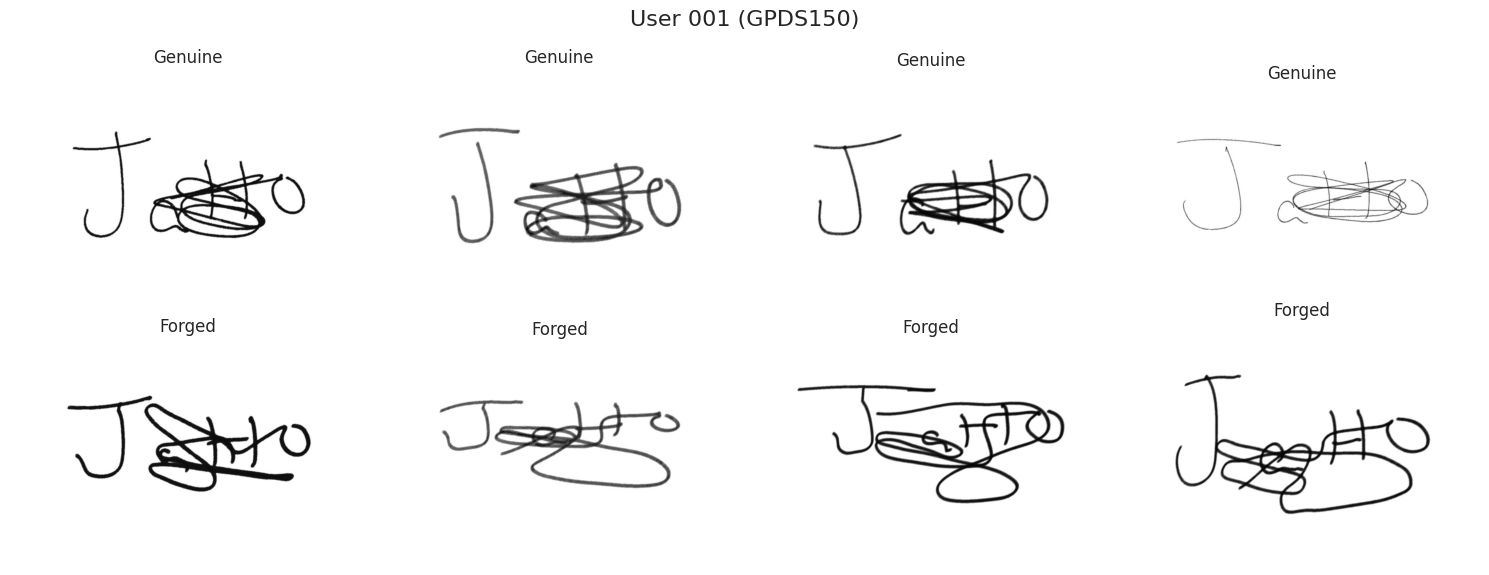

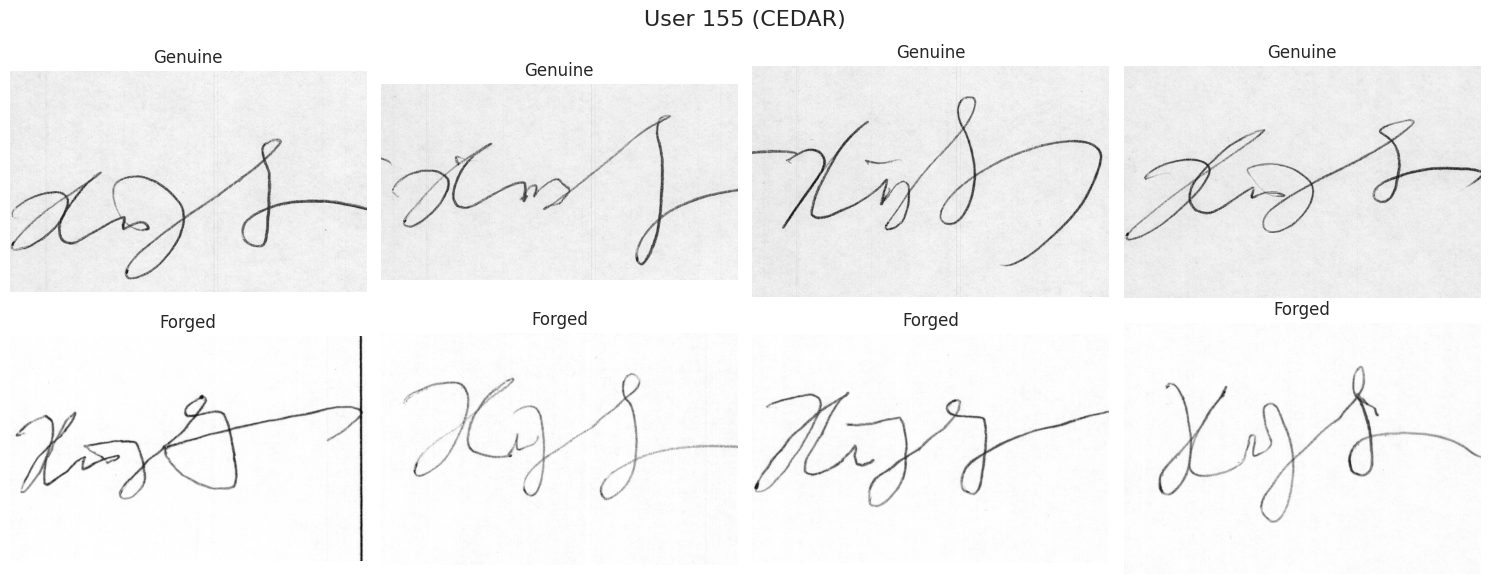

In [7]:
def visualize_user_signatures(user_id, df, num_samples=5):
    """
    Plots a row of genuine and a row of forged signatures for a specific user.
    """
    user_data = df[df['user_id'] == user_id]
    gen_samples = user_data[user_data['type'] == 'genuine']['file_path'].sample(num_samples, replace=False).values
    forg_samples = user_data[user_data['type'] == 'forged']['file_path'].sample(num_samples, replace=False).values

    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    fig.suptitle(f"User {user_id} ({user_data['source'].iloc[0]})", fontsize=16)

    # Plot Genuine
    for i, img_path in enumerate(gen_samples):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title("Genuine")
        axes[0, i].axis('off')

    # Plot Forged
    for i, img_path in enumerate(forg_samples):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title("Forged")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize one from GPDS (e.g., User 001)
visualize_user_signatures('001', df, num_samples=4)

# Visualize one from CEDAR (e.g., User 155)
# Note: Ensure the user ID string matches your folder name format exactly
visualize_user_signatures('155', df, num_samples=4)

Image Resolution Analysis

Analyzing 7440 images...


100%|██████████| 7440/7440 [29:01<00:00,  4.27it/s]


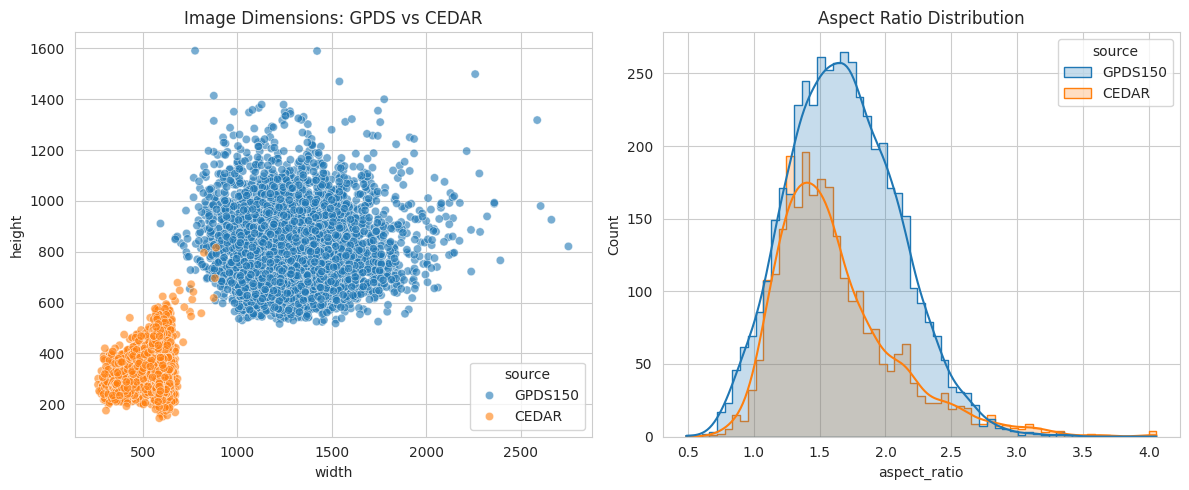

Average GPDS Size: [ 799.82104167 1304.191875  ]
Average CEDAR Size: [350.47651515 543.83977273]


In [9]:
from PIL import Image
from tqdm import tqdm # Progress bar library

# Initialize lists
widths = []
heights = []
valid_indices = [] # To keep track of images that opened successfully

print(f"Analyzing {len(df)} images...")

# Use tqdm to show a progress bar
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    try:
        # PIL.Image.open reads only metadata/headers first (Much faster)
        with Image.open(row['file_path']) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            valid_indices.append(index)
    except Exception as e:
        print(f"Error reading {row['file_path']}: {e}")

# Create a temporary dataframe for only valid images to avoid mismatch
df_valid = df.loc[valid_indices].copy()
df_valid['width'] = widths
df_valid['height'] = heights
df_valid['aspect_ratio'] = df_valid['width'] / df_valid['height']

# --- Visualization ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_valid, x='width', y='height', hue='source', alpha=0.6)
plt.title("Image Dimensions: GPDS vs CEDAR")

plt.subplot(1, 2, 2)
sns.histplot(data=df_valid, x='aspect_ratio', hue='source', kde=True, element="step")
plt.title("Aspect Ratio Distribution")

plt.tight_layout()
plt.show()

print("Average GPDS Size:", df_valid[df_valid['source']=='GPDS150'][['height', 'width']].mean().values)
print("Average CEDAR Size:", df_valid[df_valid['source']=='CEDAR'][['height', 'width']].mean().values)

Pixel Intensity Analysis

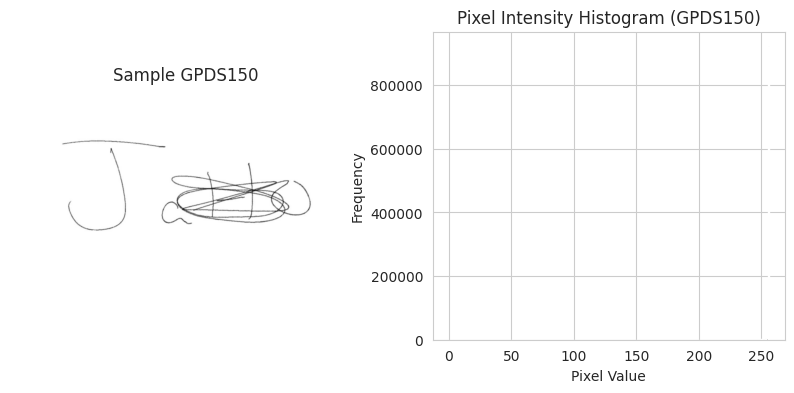

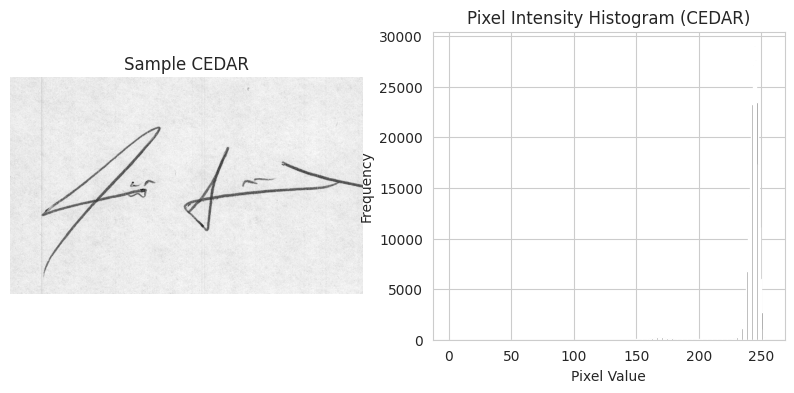

In [10]:
def plot_pixel_distribution(df, source_name):
    # Sample one image from the specific source
    sample_path = df[df['source'] == source_name].iloc[0]['file_path']
    img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Sample {source_name}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.hist(img.ravel(), bins=256, range=[0, 256], color='gray')
    plt.title(f"Pixel Intensity Histogram ({source_name})")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")

    plt.show()

plot_pixel_distribution(df, 'GPDS150')
plot_pixel_distribution(df, 'CEDAR')

Ink Density Analysis

Calculating Ink Density (this may take 1-2 mins)...


/tmp/ipython-input-3634922407.py:35: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=subset_df[subset_df['type']=='genuine'], x='ink_density', label='Genuine', shade=True)
/tmp/ipython-input-3634922407.py:36: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=subset_df[subset_df['type']=='forged'], x='ink_density', label='Forged', shade=True)


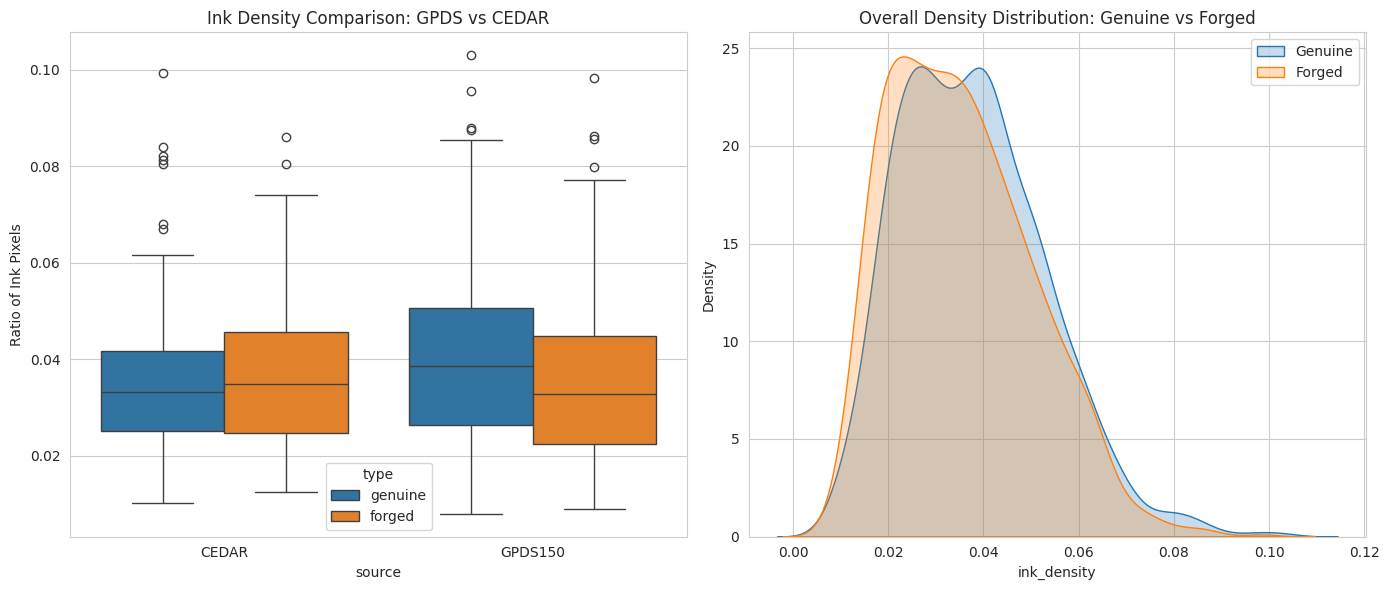

In [11]:
def calculate_ink_density(row):
    try:
        # Load as grayscale
        img = cv2.imread(row['file_path'], cv2.IMREAD_GRAYSCALE)

        # Apply Otsu's thresholding to separate ink from background
        # (Inverts image so Ink=255, Background=0 for calculation)
        _, binary_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # Calculate ratio of white pixels (which represent ink now due to inversion)
        total_pixels = binary_img.size
        ink_pixels = cv2.countNonZero(binary_img)

        return ink_pixels / total_pixels
    except Exception as e:
        return np.nan

print("Calculating Ink Density (this may take 1-2 mins)...")

# We use a subset (e.g., 2000 images) to make this fast, or remove .sample() to run on all
subset_df = df.sample(n=min(2000, len(df)), random_state=42).copy()
subset_df['ink_density'] = subset_df.apply(calculate_ink_density, axis=1)

# --- Visualization ---
plt.figure(figsize=(14, 6))

# 1. Density by Source (GPDS vs CEDAR)
plt.subplot(1, 2, 1)
sns.boxplot(data=subset_df, x='source', y='ink_density', hue='type')
plt.title("Ink Density Comparison: GPDS vs CEDAR")
plt.ylabel("Ratio of Ink Pixels")

# 2. Density Distribution (Genuine vs Forged)
plt.subplot(1, 2, 2)
sns.kdeplot(data=subset_df[subset_df['type']=='genuine'], x='ink_density', label='Genuine', shade=True)
sns.kdeplot(data=subset_df[subset_df['type']=='forged'], x='ink_density', label='Forged', shade=True)
plt.title("Overall Density Distribution: Genuine vs Forged")
plt.legend()

plt.tight_layout()
plt.show()

"Difficulty" Analysis (Intra-class vs. Inter-class Distance)

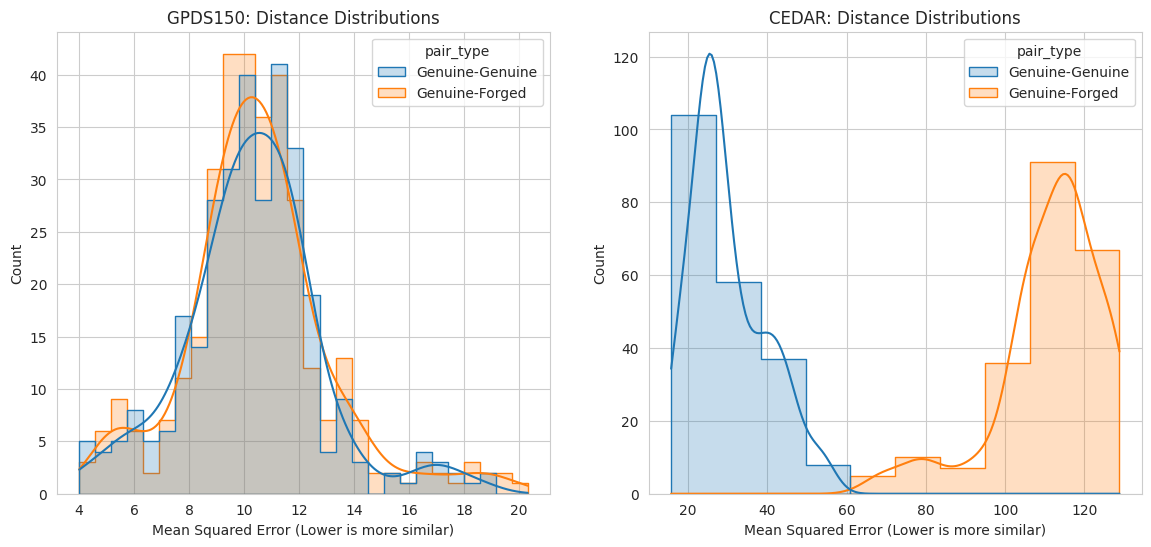

In [12]:
def calculate_mse_distances(df, num_users=20):
    distances = []

    # Select random users
    selected_users = np.random.choice(df['user_id'].unique(), num_users, replace=False)

    for user in selected_users:
        user_data = df[df['user_id'] == user]

        # Get Genuine and Forged paths
        gen_paths = user_data[user_data['type'] == 'genuine']['file_path'].tolist()
        forg_paths = user_data[user_data['type'] == 'forged']['file_path'].tolist()

        # We need at least 2 genuine images to compare
        if len(gen_paths) < 2: continue

        # Load Anchor (First genuine image)
        # Resize to small fixed size for fast comparison (e.g., 64x64)
        anchor_img = cv2.imread(gen_paths[0], cv2.IMREAD_GRAYSCALE)
        anchor_img = cv2.resize(anchor_img, (64, 64))

        # 1. Compare Anchor vs Other Genuines (Positive Distance)
        for path in gen_paths[1:]: # Skip the anchor itself
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))
            # simple MSE calculation
            mse = np.mean((anchor_img - img)**2)
            distances.append({'dist': mse, 'pair_type': 'Genuine-Genuine', 'source': user_data['source'].iloc[0]})

        # 2. Compare Anchor vs Forgeries (Negative Distance)
        for path in forg_paths:
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))
            mse = np.mean((anchor_img - img)**2)
            distances.append({'dist': mse, 'pair_type': 'Genuine-Forged', 'source': user_data['source'].iloc[0]})

    return pd.DataFrame(distances)

# Run calculation
dist_df = calculate_mse_distances(df, num_users=30) # Increase users for smoother plots

# --- Visualization ---
plt.figure(figsize=(14, 6))

# Plot for GPDS
plt.subplot(1, 2, 1)
sns.histplot(data=dist_df[dist_df['source'] == 'GPDS150'], x='dist', hue='pair_type', kde=True, element="step")
plt.title("GPDS150: Distance Distributions")
plt.xlabel("Mean Squared Error (Lower is more similar)")

# Plot for CEDAR
plt.subplot(1, 2, 2)
sns.histplot(data=dist_df[dist_df['source'] == 'CEDAR'], x='dist', hue='pair_type', kde=True, element="step")
plt.title("CEDAR: Distance Distributions")
plt.xlabel("Mean Squared Error (Lower is more similar)")

plt.show()

In [13]:
from scipy.stats import entropy

def extract_advanced_features(row):
    try:
        # Load image lazily just to get stats
        img = cv2.imread(row['file_path'], cv2.IMREAD_GRAYSCALE)
        h, w = img.shape

        # 1. Geometric Features
        area = h * w
        aspect_ratio = w / h

        # 2. Texture/Complexity Feature (Entropy)
        # Calculate histogram for entropy
        hist = cv2.calcHist([img], [0], None, [256], [0, 256])
        hist = hist / hist.sum() # Normalize
        img_entropy = entropy(hist).item() # Shannon entropy

        return pd.Series([area, aspect_ratio, img_entropy])
    except:
        return pd.Series([np.nan, np.nan, np.nan])

print("Extracting features for full dataset (Area, Aspect Ratio, Entropy)...")
# Apply to the dataframe
df[['area', 'aspect_ratio', 'entropy']] = df.apply(extract_advanced_features, axis=1)

# Clean any failed reads
df_clean = df.dropna(subset=['area', 'aspect_ratio', 'entropy'])
print("Feature extraction complete.")

Extracting features for full dataset (Area, Aspect Ratio, Entropy)...
Feature extraction complete.


Aspect Ratio Comparison (Shape Analysis)

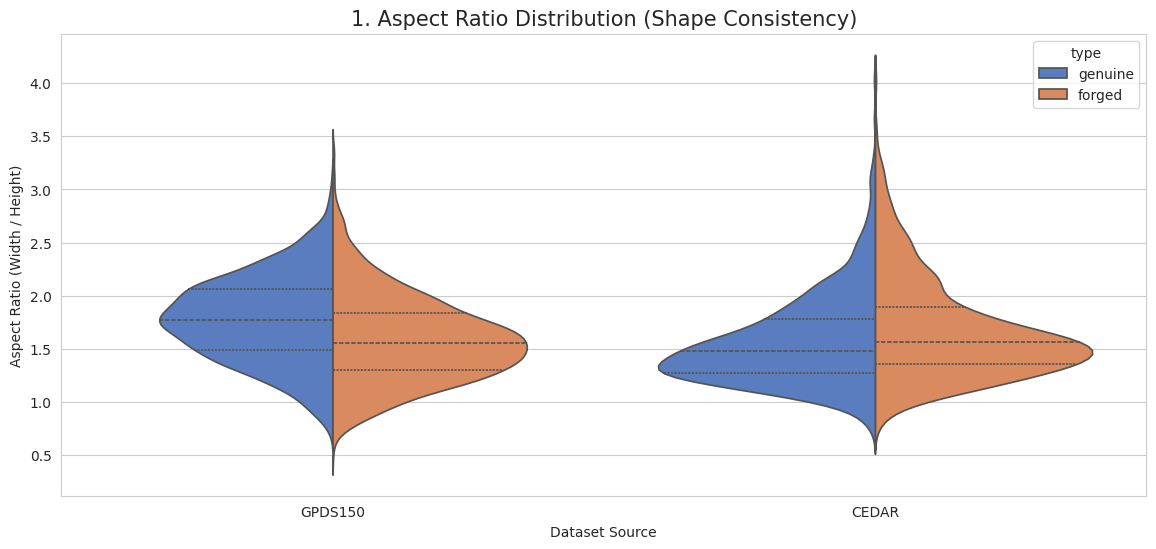

In [14]:
plt.figure(figsize=(14, 6))

# We use a violin plot to see the density of the data
sns.violinplot(data=df_clean, x='source', y='aspect_ratio', hue='type',
               split=True, inner="quart", palette="muted")

plt.title("1. Aspect Ratio Distribution (Shape Consistency)", fontsize=15)
plt.ylabel("Aspect Ratio (Width / Height)")
plt.xlabel("Dataset Source")
plt.show()

Image Area Analysis (Scale Analysis)

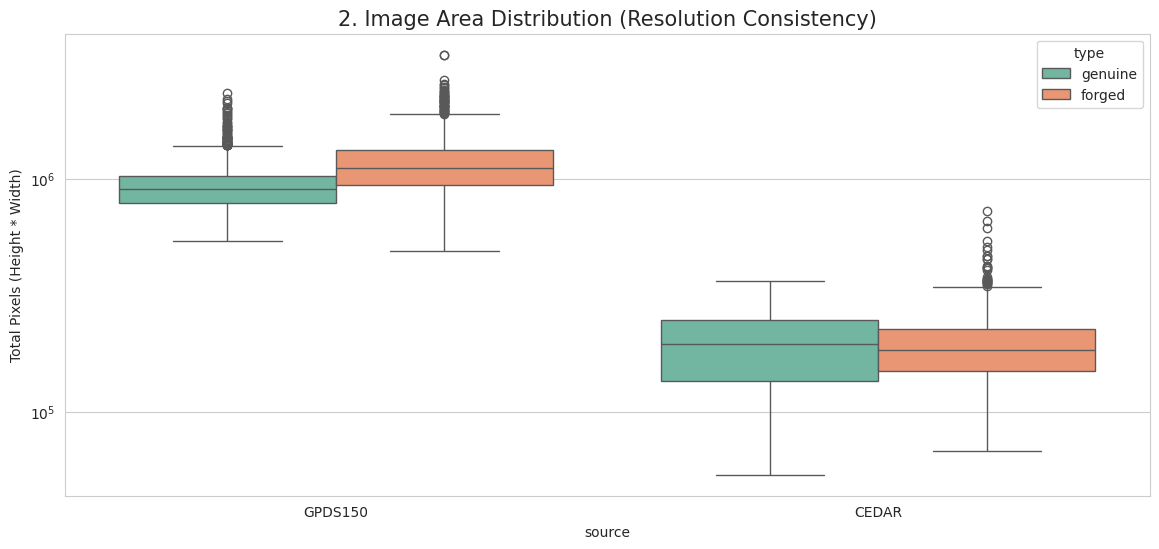

In [15]:
plt.figure(figsize=(14, 6))

# Boxplot to handle the scale differences better than violin
sns.boxplot(data=df_clean, x='source', y='area', hue='type', palette="Set2")

plt.title("2. Image Area Distribution (Resolution Consistency)", fontsize=15)
plt.ylabel("Total Pixels (Height * Width)")
plt.yscale('log') # Log scale because CEDAR might be much bigger than GPDS
plt.show()

Shannon Entropy (Stroke Complexity Analysis)

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_a

<Figure size 1400x600 with 0 Axes>

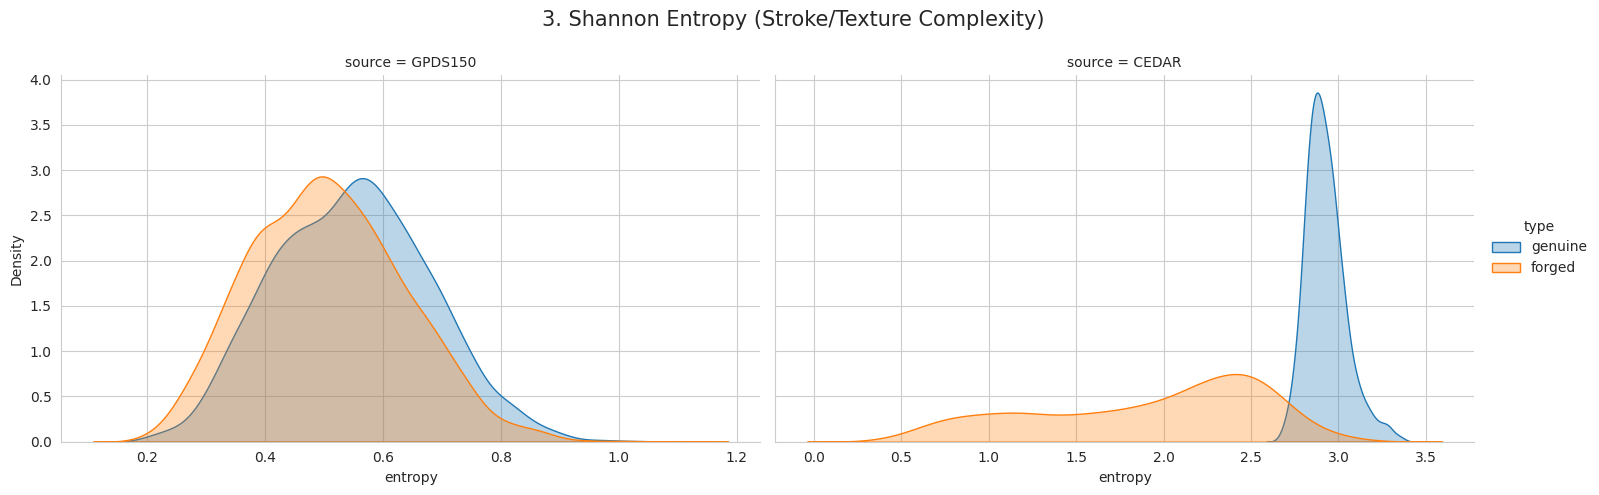

In [16]:
plt.figure(figsize=(14, 6))

# KDE Plot to visualize the overlap
# We split by source because GPDS and CEDAR likely have different scan qualities
g = sns.FacetGrid(df_clean, col="source", hue="type", height=5, aspect=1.5, sharex=False)
g.map(sns.kdeplot, "entropy", shade=True, alpha=0.3)
g.add_legend()

plt.subplots_adjust(top=0.85)
g.fig.suptitle("3. Shannon Entropy (Stroke/Texture Complexity)", fontsize=15)
plt.show()

Global Total

/tmp/ipython-input-1845571148.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(x='type', data=df, palette='magma')


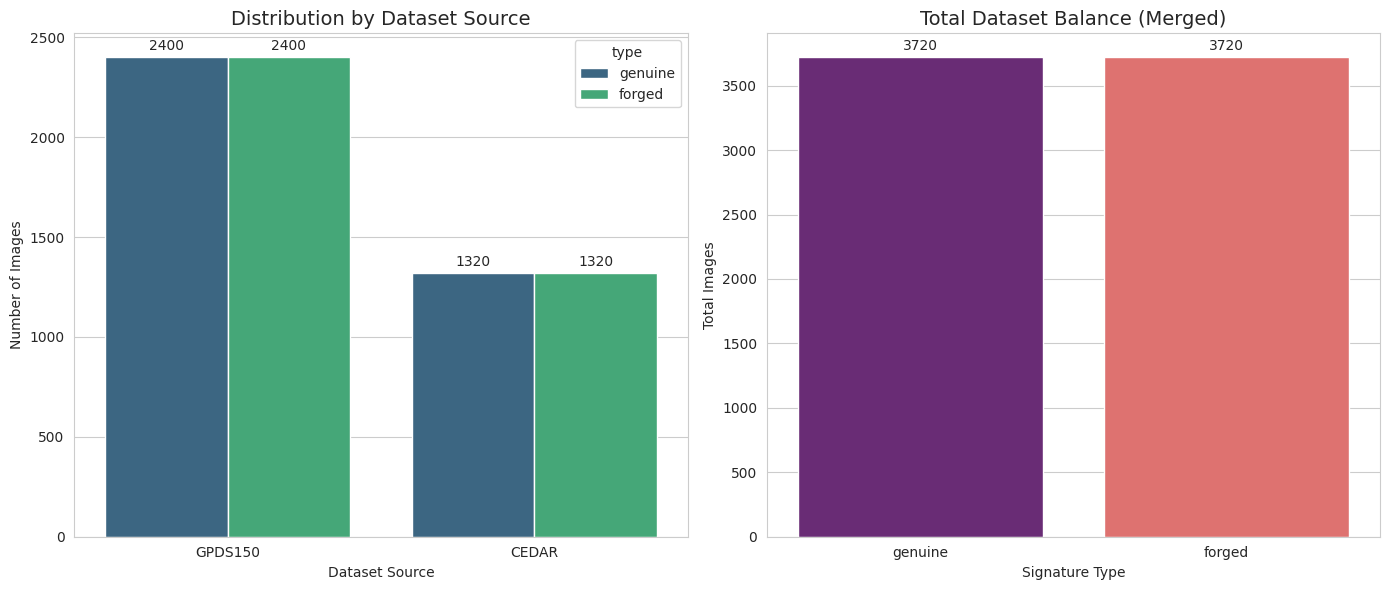

In [17]:
plt.figure(figsize=(14, 6))

# --- Plot 1: Breakdown by Source (GPDS vs CEDAR) ---
plt.subplot(1, 2, 1)
ax1 = sns.countplot(x='source', hue='type', data=df, palette='viridis')
plt.title("Distribution by Dataset Source", fontsize=14)
plt.xlabel("Dataset Source")
plt.ylabel("Number of Images")

# Add count labels on top of bars
for container in ax1.containers:
    ax1.bar_label(container, padding=3)

# --- Plot 2: Total Dataset Balance (Genuine vs Forged) ---
plt.subplot(1, 2, 2)
ax2 = sns.countplot(x='type', data=df, palette='magma')
plt.title("Total Dataset Balance (Merged)", fontsize=14)
plt.xlabel("Signature Type")
plt.ylabel("Total Images")

# Add count labels on top of bars
for container in ax2.containers:
    ax2.bar_label(container, padding=3)

plt.tight_layout()
plt.show()